# 01 — Exploratory Data Analysis
IEEE-CIS Fraud Detection

In [2]:
# Install Kaggle
!pip install kaggle

In [3]:
# Upload your kaggle.json when prompted
from google.colab import files
files.upload()  # select your kaggle.json file from your computer

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aayushi1408","key":"20781fe139421b95eb2038231d2eda23"}'}

In [4]:
# Move it to the right place
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
# Download the dataset
!kaggle competitions download -c ieee-fraud-detection

ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
# Step 1 — unzip directly in Colab (no path needed)
!unzip ieee-fraud-detection.zip

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


In [9]:
# Step 2 — create the folder in Drive
!mkdir -p /content/drive/MyDrive/fraud-detection/data/raw

In [10]:
# Step 3 — move the files to Drive
!mv train_transaction.csv train_identity.csv test_transaction.csv test_identity.csv /content/drive/MyDrive/fraud-detection/data/raw/

In [11]:
!ls /content/drive/MyDrive/fraud-detection/data/raw/

test_identity.csv     train_identity.csv
test_transaction.csv  train_transaction.csv


In [12]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
trans = pd.read_csv('/content/drive/MyDrive/fraud-detection/data/raw/train_transaction.csv', low_memory=False)
identity = pd.read_csv('/content/drive/MyDrive/fraud-detection/data/raw/train_identity.csv', low_memory=False)
df = trans.merge(identity, on='TransactionID', how='left')
print(df.shape)

(590540, 434)


In [13]:
# Class imbalance
print(df['isFraud'].value_counts(normalize=True))

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [14]:
# Missing values
null_pct = df.isnull().mean().sort_values(ascending=False)
print(null_pct[null_pct > 0.5].head(20))

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123
dtype: float64


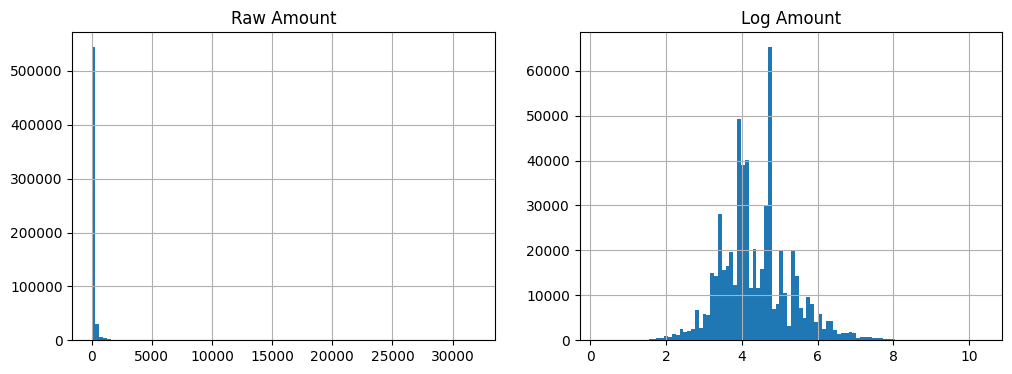

In [15]:
# Transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['TransactionAmt'].hist(bins=100, ax=axes[0])
axes[0].set_title('Raw Amount')
np.log1p(df['TransactionAmt']).hist(bins=100, ax=axes[1])
axes[1].set_title('Log Amount')
plt.show()

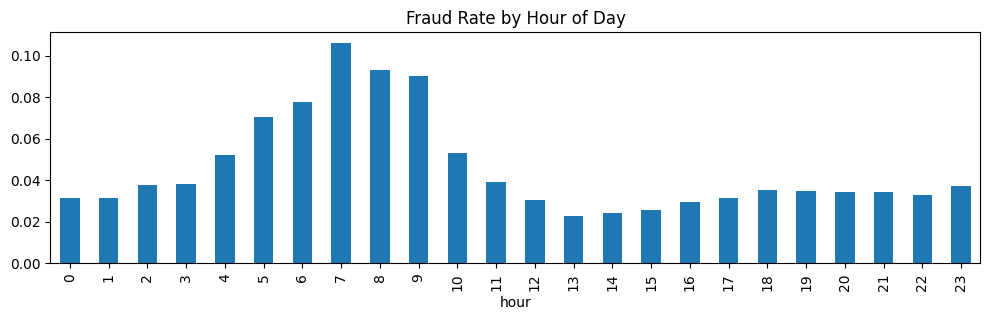

In [16]:
# Fraud rate by hour of day
df['hour'] = (df['TransactionDT'] / 3600).astype(int) % 24
df.groupby('hour')['isFraud'].mean().plot(kind='bar', figsize=(12, 3))
plt.title('Fraud Rate by Hour of Day')
plt.show()

In [17]:
# Card velocity features
df['card_txn_count'] = df.groupby('card1')['TransactionID'].transform('count')
df['card_avg_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['amt_vs_card_avg'] = df['TransactionAmt'] / (df['card_avg_amt'] + 1)
df.groupby('isFraud')[['amt_vs_card_avg', 'card_txn_count']].mean()

,amt_vs_card_avg,card_txn_count
isFraud,,
0,0.983754,2535.854537
1,1.168668,2334.680734
